# Phase 1 — Transformer Foundation

Every piece of the model, checked before moving on. No data, no training: does the architecture work?

In [1]:
import math
import os
import sys

for candidate in (os.getcwd(), os.path.dirname(os.getcwd())):
    if os.path.isdir(os.path.join(candidate, "src")):
        sys.path.insert(0, candidate)
        break

import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from src.attention import MultiHeadAttention
from src.config import TransformerConfig, get_device
from src.layers import DecoderLayer, EncoderLayer, FeedForward
from src.masking import make_causal_mask, make_decoder_mask, make_pad_mask
from src.positional import PositionalEncoding
from src.transformer import build_model

%matplotlib inline
torch.manual_seed(0)

print("Device:", get_device())

Device: cuda


## 1. Masks

Attention lets every position see every other one. Two cases where that is wrong: **padding**, the filler that makes short sentences match the batch length, and **the future**, which the decoder must not peek at or it learns to cheat during training.

`True` = allowed, `False` = blocked. Below, `0` is `<pad>`.

In [2]:
tokens = torch.tensor([
    [5, 8, 2, 9, 4],
    [7, 3, 6, 0, 0],
])
tokens

tensor([[5, 8, 2, 9, 4],
        [7, 3, 6, 0, 0]])

### Padding mask

`(batch, 1, 1, seq_len)` — the size-1 dims broadcast over heads and queries, which is why one `masked_fill` covers every attention type.

It marks columns (keys), not rows: "nobody may attend here".

In [3]:
pad_mask = make_pad_mask(tokens, pad_idx=0)

print("shape     ", tuple(pad_mask.shape))
print("sentence 0", pad_mask[0, 0, 0].int().tolist())
print("sentence 1", pad_mask[1, 0, 0].int().tolist())

shape      (2, 1, 1, 5)
sentence 0 [1, 1, 1, 1, 1]
sentence 1 [1, 1, 1, 0, 0]


### Causal mask

Lower-triangular. Row = who is looking, column = what they can see.

In [4]:
causal_mask = make_causal_mask(5)

print("shape", tuple(causal_mask.shape))
for i, row in enumerate(causal_mask[0, 0].int().tolist()):
    print(f"  {i} sees {row}")

shape (1, 1, 5, 5)
  0 sees [1, 0, 0, 0, 0]
  1 sees [1, 1, 0, 0, 0]
  2 sees [1, 1, 1, 0, 0]
  3 sees [1, 1, 1, 1, 0]
  4 sees [1, 1, 1, 1, 1]


### Decoder mask

Both rules at once. The shapes differ — `(B,1,1,T) & (1,1,T,T)` — and broadcasting expands them into `(B,1,T,T)`.

In [5]:
dec_mask = make_decoder_mask(tokens, pad_idx=0)

print("shape", tuple(dec_mask.shape))
for i, row in enumerate(dec_mask[1, 0].int().tolist()):
    print(f"  {i}: {row}")

shape (2, 1, 5, 5)
  0: [1, 0, 0, 0, 0]
  1: [1, 1, 0, 0, 0]
  2: [1, 1, 1, 0, 0]
  3: [1, 1, 1, 0, 0]
  4: [1, 1, 1, 0, 0]


## 2. Positional encoding

Attention computes the same thing for "dog bites man" and "man bites dog" — a weighted sum has no sense of order. A distinct fixed vector added to each position supplies it.

Values stay in `[-1, 1]`, so embeddings scaled by `sqrt(d_model)` are never swamped. The table is a registered buffer, not a parameter: it moves with `.to(device)`, but the optimiser never touches it.

In [6]:
d_model = 64
pos_enc = PositionalEncoding(d_model, max_len=100, dropout=0.0)

dummy = torch.zeros(1, 20, d_model)
encoded = pos_enc(dummy)
pe = pos_enc.pe[0]

print("in  ", tuple(dummy.shape))
print("out ", tuple(encoded.shape))
print("range [%.3f, %.3f]" % (pe.min(), pe.max()))
print("in parameters()?", any(p is pos_enc.pe for p in pos_enc.parameters()))

in   (1, 20, 64)
out  (1, 20, 64)
range [-1.000, 1.000]
in parameters()? False


Cosine similarity of position 5 against 0–19 — should peak at 5 and fall off with distance.

In [7]:
sim = torch.nn.functional.cosine_similarity(pe[5].unsqueeze(0), pe[:20], dim=-1)

print(" ".join(f"{v:.2f}" for v in sim.tolist()))

0.73 0.75 0.80 0.88 0.97 1.00 0.97 0.88 0.80 0.75 0.73 0.74 0.73 0.70 0.67 0.66 0.66 0.67 0.66 0.63


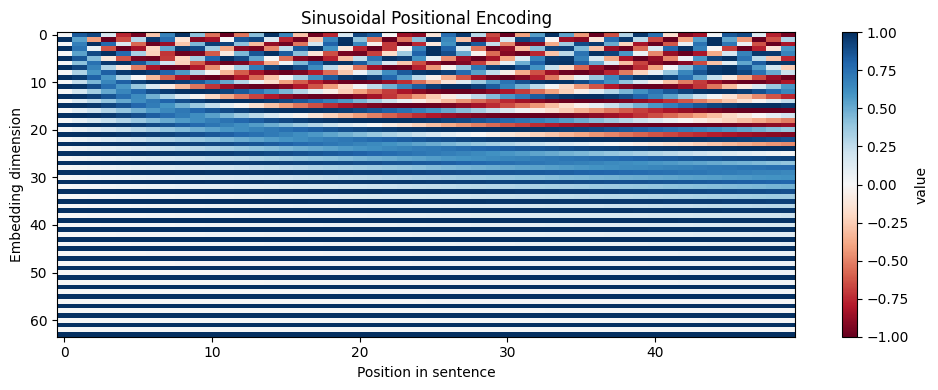

In [8]:
plt.figure(figsize=(10, 4))
plt.imshow(pe[:50].T.numpy(), cmap="RdBu", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="value")
plt.xlabel("Position in sentence")
plt.ylabel("Embedding dimension")
plt.title("Sinusoidal Positional Encoding")
plt.tight_layout()
plt.show()

## 3. Multi-head attention

One class, three uses. They differ only in what is passed as Q/K/V and which mask:

| Use | Q | K, V | Mask |
|---|---|---|---|
| Encoder self-attention | encoder input | encoder input | padding |
| Decoder self-attention | decoder input | decoder input | causal |
| Cross-attention | decoder | encoder output | source padding |

In [9]:
batch, src_len, tgt_len, d_model, num_heads = 2, 5, 7, 64, 4

mha = MultiHeadAttention(d_model, num_heads, dropout=0.0).eval()

src = torch.randn(batch, src_len, d_model)
tgt = torch.randn(batch, tgt_len, d_model)

print(f"d_model={d_model}  num_heads={num_heads}  head_dim={mha.head_dim}")

d_model=64  num_heads=4  head_dim=16


### Encoder self-attention

Q = K = V = source, padding masked. Rows sum to 1, and padding gets exactly zero.

In [10]:
out, weights = mha(src, src, src, pad_mask)

print("output ", tuple(out.shape))
print("weights", tuple(weights.shape))
print("rows sum to 1?", torch.allclose(weights.sum(-1), torch.ones(batch, num_heads, src_len)))
print("weight on padding: %.10f" % weights[1, :, :, 3:].max())

output  (2, 5, 64)
weights (2, 4, 5, 5)
rows sum to 1? True
weight on padding: 0.0000000000


### Decoder self-attention

Same call, causal mask instead. Nothing above the diagonal survives.

In [11]:
tgt_causal = make_causal_mask(tgt_len)
out2, weights2 = mha(tgt, tgt, tgt, tgt_causal)

print("output", tuple(out2.shape))
print("weight above diagonal: %.10f" % torch.triu(weights2[0, 0], diagonal=1).max())

output (2, 7, 64)
weight above diagonal: 0.0000000000


### Cross-attention

Q = target, K = V = source — where translation happens: the generated sentence looks at the one being translated. Lengths differ, and the output follows the query. The weights are the alignment matrix.

In [12]:
out3, weights3 = mha(tgt, src, src, pad_mask)

print("query len", tgt_len, " key len", src_len)
print("output ", tuple(out3.shape))
print("weights", tuple(weights3.shape))

query len 7  key len 5
output  (2, 7, 64)
weights (2, 4, 7, 5)


## 4. Encoder and decoder blocks

Attention mixes across positions, feed-forward processes each alone. Mix, then think — the pattern the whole transformer is built from.

In [13]:
d_ff = 256
ff = FeedForward(d_model, d_ff, dropout=0.0)

print(tuple(src.shape), "->", tuple(ff(src).shape))

(2, 5, 64) -> (2, 5, 64)


**EncoderLayer** — self-attention, feed-forward.

In [14]:
enc_layer = EncoderLayer(d_model, num_heads, d_ff, dropout=0.0).eval()
enc_out, enc_w = enc_layer(src, pad_mask)

print(tuple(src.shape), "->", tuple(enc_out.shape))

(2, 5, 64) -> (2, 5, 64)


**DecoderLayer** — causal self-attention, cross-attention, feed-forward. Shape preserved, so they stack.

In [15]:
dec_layer = DecoderLayer(d_model, num_heads, d_ff, dropout=0.0).eval()
dec_out, self_w, cross_w = dec_layer(tgt, enc_out, tgt_causal, pad_mask)

print(tuple(tgt.shape), "->", tuple(dec_out.shape))
print("self-attention ", tuple(self_w.shape))
print("cross-attention", tuple(cross_w.shape))

(2, 7, 64) -> (2, 7, 64)
self-attention  (2, 4, 7, 7)
cross-attention (2, 4, 7, 5)


## 5. The full model

In [16]:
config = TransformerConfig(vocab_size=10000)
model = build_model(config)
config

TransformerConfig(vocab_size=10000, d_model=256, num_heads=4, num_layers=3, d_ff=1024, dropout=0.1, max_len=5000, pad_idx=0, use_pointer=False)

Logits come out raw, not softmaxed — `CrossEntropyLoss` applies log-softmax itself, and doing it twice gives a model that trains but never learns. One cross-attention tensor comes back per decoder layer.

In [17]:
src_tokens = torch.tensor([
    [4, 17, 25, 9, 33],
    [8, 12, 40, 0, 0],
])
tgt_tokens = torch.tensor([
    [1, 6, 19, 27, 14, 8],
    [1, 22, 31, 0, 0, 0],
])

model.eval()
with torch.no_grad():
    logits, cross_attns = model(src_tokens, tgt_tokens, return_attn=True)

print("logits", tuple(logits.shape))
print("cross-attention:", len(cross_attns), "tensors of", tuple(cross_attns[0].shape))

logits (2, 6, 10000)
cross-attention: 3 tensors of (2, 4, 6, 5)


### Weight tying

Source embedding, target embedding and output projection are one matrix. Shakespeare and modern English share ~70% of their tokens, so tying makes copying nearly free — and it removes the largest single tensor from the parameter count.

In [18]:
print("share memory:", model.src_embed.weight.data_ptr() == model.generator.weight.data_ptr())
print("src_embed is tgt_embed:", model.src_embed is model.tgt_embed)
print("untied cost: %s extra parameters" % f"{config.vocab_size * config.d_model:,}")

share memory: True
src_embed is tgt_embed: True
untied cost: 2,560,000 extra parameters


In [19]:
for name, count in model.count_parameters().items():
    print(f"{name:<14} {count:>12,}")

src_embed         2,560,000
encoder           2,366,720
decoder           3,154,688
TOTAL             8,081,408


## 6. Gradient reach

Every shape check above would still pass with a branch accidentally detached from the graph; this catches that. Untrained, the loss should sit near `ln(vocab_size)`.

In [20]:
model.train()
logits = model(src_tokens, tgt_tokens)

loss = nn.CrossEntropyLoss(ignore_index=config.pad_idx)(
    logits[:, :-1].reshape(-1, config.vocab_size),
    tgt_tokens[:, 1:].reshape(-1),
)
loss.backward()

missing = [n for n, p in model.named_parameters() if p.requires_grad and p.grad is None]

print("loss %.4f   ln(vocab) %.4f" % (loss.item(), math.log(config.vocab_size)))
print("no gradient:", missing or "none")

loss 9.1442   ln(vocab) 9.2103
no gradient: none


## Done

Architecture runs and gradients flow. Not yet shown to *learn* — that needs the toy copy task, next.